In [48]:
#importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

In [49]:
#Se definen parámetros 

#Probabilidad del bits
p0 = 0.5
p1 = 1-p0

#Número de bits de la secuencia a generar
N=300

#Parámetros de modulación M-ASK
formato='polar' 
M=16
n = int(np.log2(M))
Ts = 0.001
# parámetros

#parámetros para la gráfica
fmuestreo = 100000
fc = 10000


In [50]:
def generador_secuencia(n, p0, p1, semilla=None):
    # validación
    if not np.isclose(p0 + p1, 1):
        raise ValueError("Las probabilidades deben cumplir: p0 + p1 = 1")
    rng = np.random.default_rng(semilla)
    return rng.choice([0, 1], size=n, p=[p0, p1])

# ejemplo
secuencia = generador_secuencia(N, p0, p1, semilla=42)
print(secuencia)

[1 0 1 1 0 1 1 1 0 0 0 1 1 1 0 0 1 0 1 1 1 0 1 1 1 0 0 0 0 1 1 1 0 0 0 0 0
 0 0 1 0 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 0 0 0 0 1 0
 0 0 0 1 1 1 1 0 1 0 0 0 1 0 0 1 0 1 0 0 0 1 0 0 0 1 1 1 0 1 1 1 0 0 0 1 0
 0 0 1 0 1 1 1 0 1 1 1 0 0 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 0 0 1 1 0 0 0 1
 0 0 1 1 0 1 0 1 0 1 1 1 0 1 0 0 1 0 1 1 0 1 0 1 0 1 0 0 0 1 1 1 1 1 1 0 1
 1 0 0 1 0 1 0 0 1 0 0 1 1 0 0 1 1 1 0 0 0 0 1 0 1 1 1 0 1 1 1 0 0 1 0 0 0
 1 1 0 1 0 1 1 0 0 0 1 1 1 1 0 1 0 0 1 1 0 1 1 1 1 0 0 0 1 1 0 0 0 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 1 0 0 0 1 0 1 0 1 0 1 1
 1 1 1 1]


In [51]:
#Convertidor de datos


def gray_code(n):
    """Genera códigos Gray de n bits"""
    if n == 0:
        return ['']
    prev = gray_code(n-1)
    return ['0' + code for code in prev] + ['1' + code for code in reversed(prev)]


def convertidor_datos(bits, M=4, formato='polar'):
    n = int(np.log2(M))
    
    # asegurar múltiplo de n
    L = len(bits)
    if L % n != 0:
        bits = bits[:L - (L % n)]
    
    # agrupar bits
    grupos = bits.reshape(-1, n)
    
    # generar código Gray
    gray = gray_code(n)
    
    # mapping: binario -> índice Gray
    mapping = {tuple(int(b) for b in gray[i]): i for i in range(M)}
    
    # convertir grupos a índices
    indices = [mapping[tuple(grupo)] for grupo in grupos]
    indices = np.array(indices)
    
    # niveles M-ASK
    if formato == 'polar':
        # niveles simétricos
        niveles = 2*indices - (M - 1)
    elif formato == 'unipolar':
        niveles = indices

    else:
        raise ValueError("Formato debe ser 'polar' o 'unipolar'")
    
    return niveles


Ik = convertidor_datos(secuencia, M, formato)
print(Ik)
    

[ 11  -5 -13   1  11  11  15  -5 -15 -13  -7   1  15   5  -1  11   7 -15
  15  -5   9  -9  -3 -13 -13   3   1  -1  -3   3   1 -15  -3   9   9 -11
 -13 -11  -3  -5  -1  11  -3  -1  -5   7   1   9  -1   1   7 -13  -5  -5
  -9 -11  -3  15   5  -1   3   7 -11 -13  13  -1  15 -15  -7  -5 -15  15
   9  11   5]


In [52]:
def pulso_rectangular(t, Ts, fmuestreo):
    eps = 1/(2*fmuestreo)
    return np.where((t >= -eps) & (t < Ts - eps), 1.0, 0.0)

def xi(simbolos, Ts, fmuestreo):
    Ns = int(Ts * fmuestreo)
    t = np.arange(len(simbolos) * Ns) / fmuestreo
    s = np.zeros_like(t, dtype=float)
    
    for k, a_k in enumerate(simbolos):
        s += a_k * pulso_rectangular(t - k*Ts, Ts, fmuestreo)
    return t, s
# señal banda base
t, s = xi(Ik[:20], Ts, fmuestreo)
# portadora
portadora = np.cos(2 * np.pi * fc * t)

# señal modulada
x = s * portadora




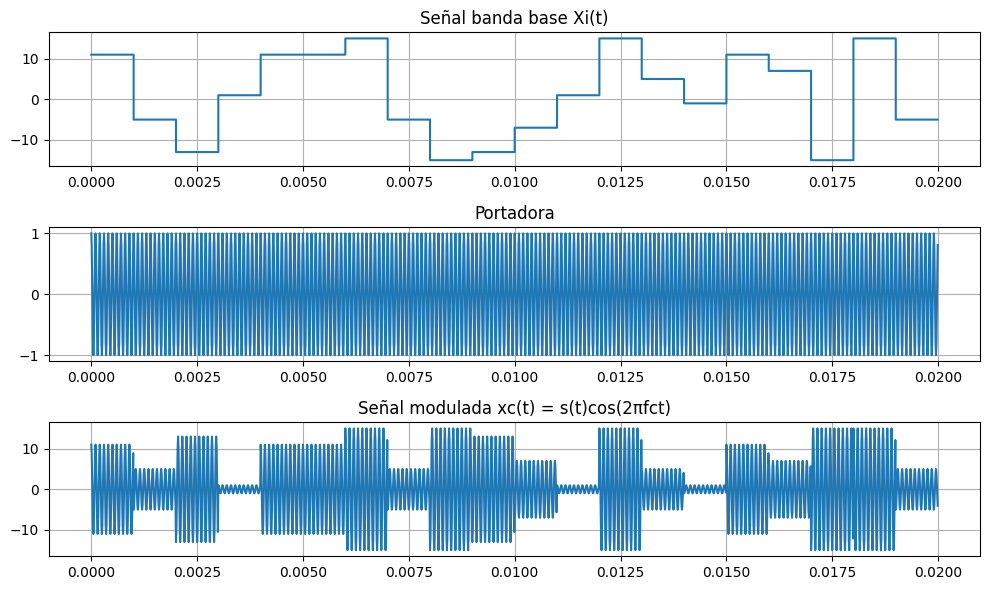

In [53]:
# gráficos
plt.figure(figsize=(10,6))

plt.subplot(3,1,1)
plt.step(t, s, where='post')
plt.title("Señal banda base Xi(t)")
plt.grid()

plt.subplot(3,1,2)
plt.plot(t, portadora)
plt.title("Portadora")
plt.grid()

plt.subplot(3,1,3)
plt.plot(t, x)
plt.title("Señal modulada xc(t) = s(t)cos(2πfct)")
plt.grid()

plt.tight_layout()
plt.show()

In [67]:
#Densidad Espectral de Potencia (DEP)
p0

if formato == 'polar':
    tabla = dict(zip(gray_code(n),[2*i - (M-1) for i in range(M)] ))
else: 
    tabla = dict(zip(gray_code(n), [i for i in range(M)]))
    
print(tabla['0000'])



-3


In [68]:
def prob_simbolo(bits, p0, p1):
    prob = 1
    for b in bits:
        if b == '0':
            prob *= p0
        else:
            prob *= p1
    return prob

P_ak = {tabla[bits]: prob_simbolo(bits, p0, p1) for bits in tabla}

print(P_ak)

{-3: 0.0625, -1: 0.0625, 1: 0.0625, 3: 0.0625}
